In [1]:
from umap import UMAP
from sklearn.manifold import TSNE, MDS

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from itertools import product
import warnings

warnings.filterwarnings("ignore")

from zadu.measures import class_aware_trustworthiness_continuity


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dist_mat = np.load('dist_mat.npy')
labels = np.load('ship-types.npy')
original_data = np.load('original_data.npy')

print("Original data shape:", original_data.shape)

global_all_results = []



Original data shape: (750, 25, 10)


# MDS

In [3]:
def plot_mds(
    data,
    original_data,
    labels,
    ax=None,
    random_state=42,
    n_init=4,
    max_iter=300,
    eps=1e-6,
    normalized_stress="auto",
    title="MDS"
):
    # FIXED: dissimilarity="precomputed", metric=True, removed init
    embedding = MDS(
        n_components=2,
        dissimilarity="precomputed",  
        metric=True,                  
        random_state=random_state,
        n_init=n_init,                
        max_iter=max_iter,
        eps=eps,
        normalized_stress=normalized_stress
    ).fit_transform(data)

    if ax is None:
        ax = plt.gca()

    sns.scatterplot(
        x=embedding[:, 0],
        y=embedding[:, 1],
        hue=labels,
        palette="tab10",
        s=25,
        alpha=0.8,
        legend=False,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel("MDS 1")
    ax.set_ylabel("MDS 2")

    original_flat = original_data.reshape(len(original_data), -1)

    trust_scores = []
    cont_scores = []
    knn_scores = []

    for k in range(5, 30):
        ca_tc = class_aware_trustworthiness_continuity.measure(
            original_flat,
            embedding,
            label=labels,
            k=k
        )

        trust_scores.append(ca_tc["ca_trustworthiness"] / 25)
        cont_scores.append(ca_tc["ca_continuity"] / 25)

        knn = KNeighborsClassifier(n_neighbors=k)
        knn_scores.append(cross_val_score(knn, embedding, labels, cv=5).mean())

    trust_score = float(np.mean(trust_scores))
    cont_score = float(np.mean(cont_scores))
    knn_score = float(np.mean(knn_scores))
    best_k = int(np.argmax(knn_scores) + 5)

    print(
        f"{title} | "
        f"CA Cont {cont_score:.4f} | "
        f"CA Trust {trust_score:.4f} | "
        f"KNN {knn_score:.3f} | "
        f"Geriausias k KNN {best_k}"
    )

    return embedding, {
        "ca_continuity": cont_score,
        "ca_trustworthiness": trust_score,
        "knn_accuracy": knn_score,
        "best_k": best_k
    }



In [4]:
def plot_mds_param(
    param_name,
    param_values,
    distance_matrix,
    original_data,
    labels,
    random_state=42
):
    n = len(param_values)
    cols = min(n, 4)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    default_params = {
        "n_init": 4,
        "max_iter": 300,
        "eps": 1e-6
    }

    results = []

    for i, val in enumerate(param_values):
        params = default_params.copy()
        params[param_name] = val

        _, scores = plot_mds(
            data=distance_matrix,
            original_data=original_data,
            labels=labels,
            ax=axes[i],
            random_state=random_state,
            title=f"{param_name} = {val}",
            **params
        )

        # ADDED: Append to local and global results
        res_dict = {param_name: val, **scores}
        results.append(res_dict)
        global_all_results.append({"Method": "MDS", **res_dict})

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

    return pd.DataFrame(results)


## paleidimas

n_init = 1 | CA Cont 0.0393 | CA Trust 0.0381 | KNN 0.590 | Geriausias k KNN 5
n_init = 4 | CA Cont 0.0393 | CA Trust 0.0380 | KNN 0.599 | Geriausias k KNN 5
n_init = 8 | CA Cont 0.0393 | CA Trust 0.0380 | KNN 0.599 | Geriausias k KNN 5
n_init = 32 | CA Cont 0.0395 | CA Trust 0.0379 | KNN 0.588 | Geriausias k KNN 8


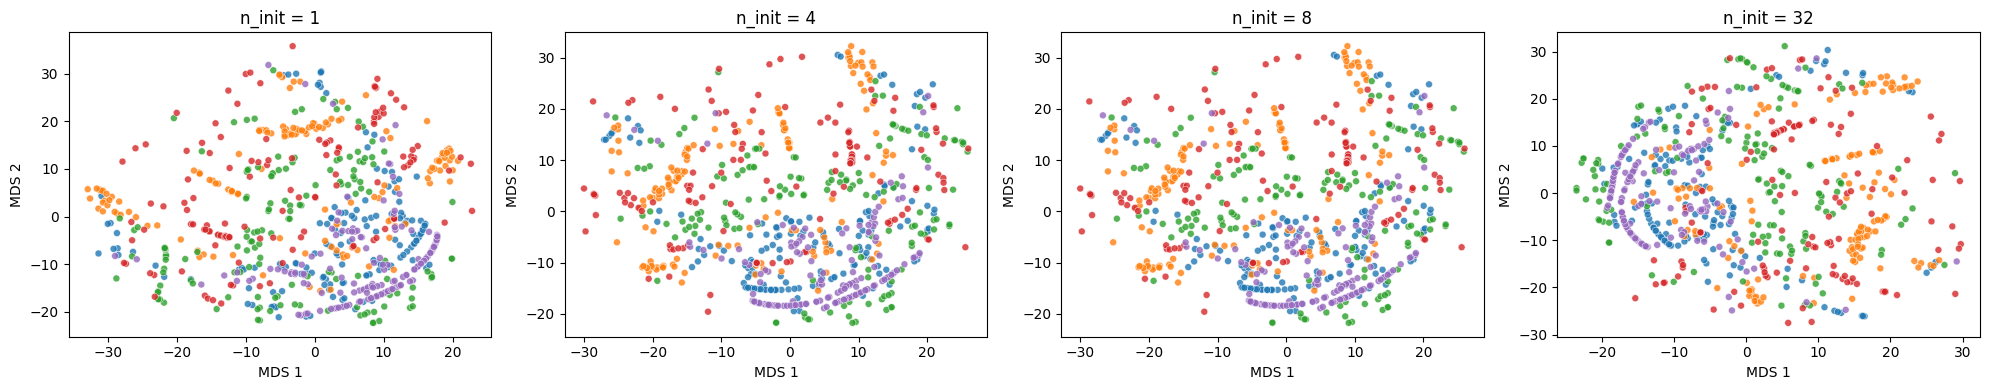

max_iter = 25 | CA Cont 0.0338 | CA Trust 0.0328 | KNN 0.450 | Geriausias k KNN 11
max_iter = 50 | CA Cont 0.0372 | CA Trust 0.0359 | KNN 0.514 | Geriausias k KNN 7
max_iter = 200 | CA Cont 0.0393 | CA Trust 0.0380 | KNN 0.599 | Geriausias k KNN 5
max_iter = 400 | CA Cont 0.0393 | CA Trust 0.0380 | KNN 0.599 | Geriausias k KNN 5


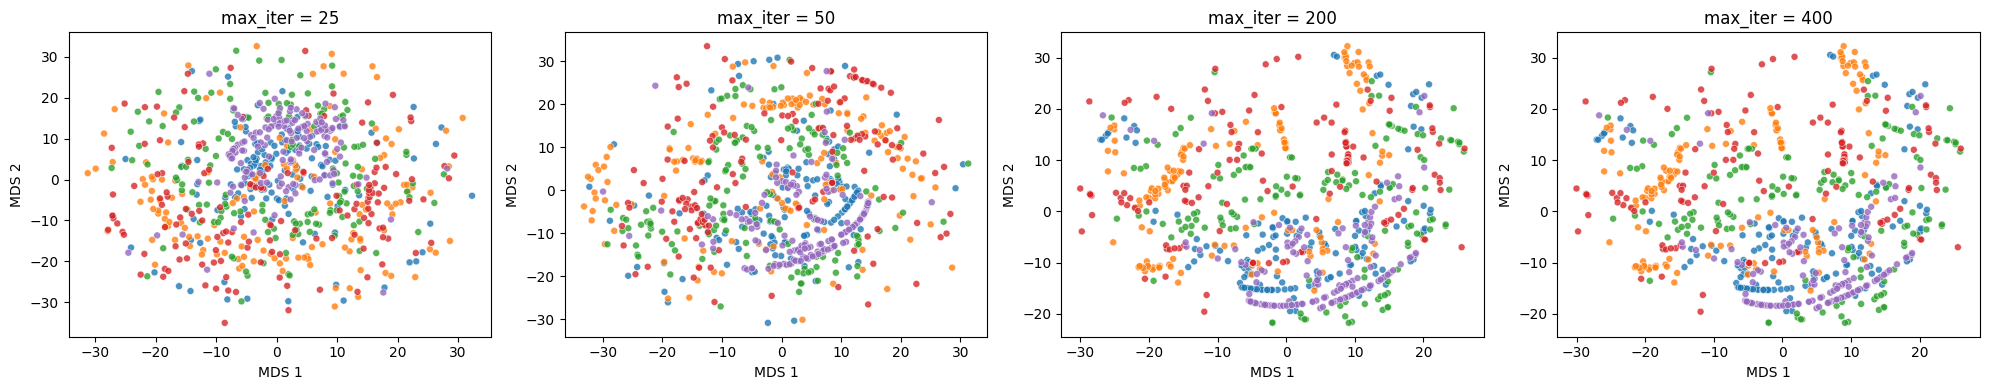

eps = 0.001 | CA Cont 0.0385 | CA Trust 0.0367 | KNN 0.563 | Geriausias k KNN 9
eps = 0.0001 | CA Cont 0.0392 | CA Trust 0.0375 | KNN 0.576 | Geriausias k KNN 5
eps = 1e-05 | CA Cont 0.0393 | CA Trust 0.0378 | KNN 0.583 | Geriausias k KNN 6
eps = 1e-06 | CA Cont 0.0393 | CA Trust 0.0380 | KNN 0.599 | Geriausias k KNN 5


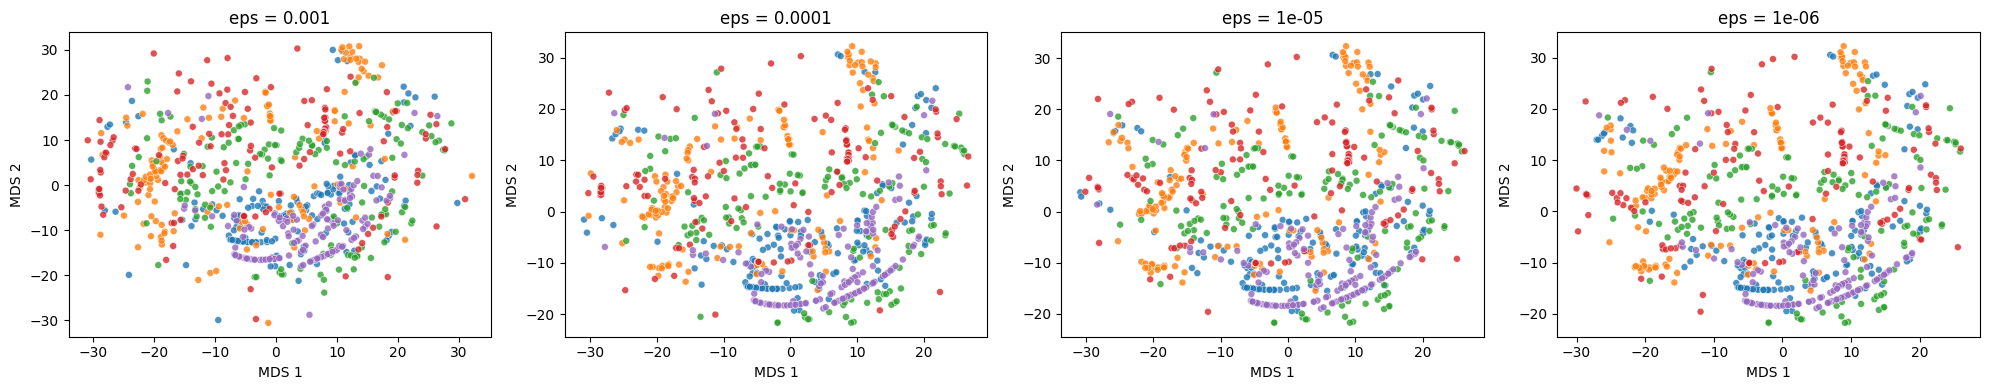

In [ ]:

default_mds_hyperparams = {
    "n_init": [1, 4, 8, 32],
    "max_iter": [25, 50, 200, 400],
    "eps": [1e-3, 1e-4, 1e-5, 1e-6],
}


In [ ]:
mds_n_init_results = plot_mds_param("n_init", default_mds_hyperparams["n_init"], dist_mat, original_data, labels)

In [ ]:
mds_max_iter_results = plot_mds_param("max_iter", default_mds_hyperparams["max_iter"], dist_mat, original_data, labels)

In [ ]:
mds_eps_results = plot_mds_param("eps", default_mds_hyperparams["eps"], dist_mat, original_data, labels)

# T-SNE

In [6]:

## =========================================================
## t-SNE tyrimas
## =========================================================
def plot_tsne(data, perplexity=0.1, early_exaggeration=100, ax=None):
    embeddings = TSNE(perplexity=perplexity, early_exaggeration=early_exaggeration)\
        .fit_transform(data)
    
    if ax is None:
        ax = plt.gca()

    print(embeddings[:, 0].shape, embeddings[:, 1].shape)
    sns.scatterplot(x=embeddings[:, 0], y=embeddings[:, 1], ax=ax, hue=labels)


In [7]:

def plot_tsne_param(param_name, param_values, distance_matrix, labels=None, random_state=42):
    n = len(param_values)
    cols = min(n, 4)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for i, val in enumerate(param_values):
        params = {param_name: val}

        max_iter = 1000 if param_name != 'max_iter' else val
        perplexity = 50 if param_name != 'perplexity' else val

        if param_name in ['max_iter', 'perplexity']:
            tsne = TSNE(
                n_components=2, metric="precomputed", random_state=random_state,
                max_iter=max_iter, perplexity=perplexity, init="random",
            )
        elif param_name == 'max_iter':
            tsne = TSNE(
                n_components=2, metric="precomputed", random_state=random_state,
                perplexity=perplexity, init="random", **params
            )
        elif param_name == 'perplexity':
            tsne = TSNE(
                n_components=2, metric="precomputed", random_state=random_state,
                max_iter=max_iter, init="random", **params
            )
        else:
            tsne = TSNE(
                n_components=2, metric="precomputed", random_state=random_state,
                init="random", **params
            )

        embedding = tsne.fit_transform(distance_matrix)
        ax = axes[i]
        original_flat = original_data.reshape(len(original_data), -1)
        
        trust_scores = []
        cont_scores = []
        knn_scores = []

        for k in range(5, 30):
            ca_tc = class_aware_trustworthiness_continuity.measure(
                original_flat, embedding, label=labels, k=k
            )
            trust_scores.append(ca_tc["ca_trustworthiness"]) # Note: your original didn't divide by 25 here
            cont_scores.append(ca_tc["ca_continuity"])
            knn = KNeighborsClassifier(n_neighbors=k)
            knn_scores.append(cross_val_score(knn, embedding, labels, cv=5).mean())

        trust_score = np.mean(trust_scores)
        cont_score = np.mean(cont_scores)
        knn_score = np.mean(knn_scores)
        best_k = np.argmax(knn_scores) + 5

        print(
            "Value:", val, "CA Continuity", cont_score, "CA Trustworthiness", trust_score,
            "KNN", knn_score, "Geriausias k KNN", best_k
        )

        if labels is not None:
            sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=labels, palette="tab10", ax=ax, legend=False)
        else:
            ax.scatter(embedding[:, 0], embedding[:, 1])

        ax.set_title(f"{param_name} = {val}")
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


## paleidimas

In [8]:

default_tsne_hyperparams = {
    "perplexity":         [5, 50, 200],
    "max_iter":             [250, 500, 2000],
    "early_exaggeration": [4.0, 12.0, 24.0],
    "learning_rate":      [10, 100, 1000],
}

keys = list(default_tsne_hyperparams.keys())
values = list(default_tsne_hyperparams.values())
tsne_results = []

for combo in product(*values):
    params = dict(zip(keys, combo))

    embedding = TSNE(
        perplexity         = params["perplexity"],
        max_iter           = params["max_iter"],
        early_exaggeration = params["early_exaggeration"],
        learning_rate      = params["learning_rate"],
        metric             = "precomputed",
        init               = "random",
        random_state       = 42,
    ).fit_transform(dist_mat)

    original_flat = original_data.reshape(len(original_data), -1)

    trust_scores = []
    cont_scores = []
    knn_scores = []

    for k in range(5, 30):
        ca_tc = class_aware_trustworthiness_continuity.measure(
            original_flat, embedding, label=labels, k=k
        )
        trust_scores.append(ca_tc["ca_trustworthiness"] / 25)
        cont_scores.append(ca_tc["ca_continuity"] / 25)

        knn = KNeighborsClassifier(n_neighbors=k)
        knn_scores.append(cross_val_score(knn, embedding, labels, cv=5).mean())

    trust_score = np.mean(trust_scores)
    cont_score = np.mean(cont_scores)
    knn_score = np.mean(knn_scores)
    best_k = np.argmax(knn_scores) + 5

    res_dict = {
        **params,
        "ca_trustworthiness": trust_score, 
        "ca_continuity": cont_score,
        "knn_accuracy": knn_score,
        "best_k": best_k
    }
    tsne_results.append(res_dict)
    global_all_results.append({"Method": "t-SNE", **res_dict})



Running t-SNE grid search...


Value: 5 CA Continuity 0.9817115916472144 CA Trustworthiness 0.9779886017805539 KNN 0.66752 Geriausias k KNN 5
Value: 50 CA Continuity 0.993423015048769 CA Trustworthiness 0.9906095571931897 KNN 0.6235733333333333 Geriausias k KNN 5
Value: 200 CA Continuity 0.9933904671472746 CA Trustworthiness 0.9863800565033997 KNN 0.6027733333333334 Geriausias k KNN 5


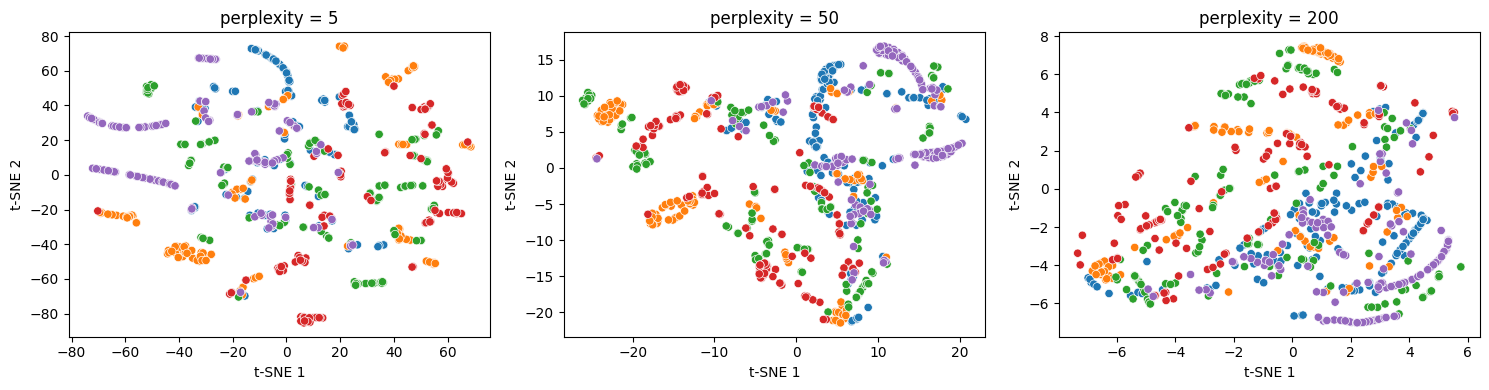

In [9]:

plot_tsne_param("perplexity", default_tsne_hyperparams['perplexity'], dist_mat, labels=labels)

In [ ]:
plot_tsne_param("max_iter", default_tsne_hyperparams['max_iter'], dist_mat, labels=labels)

In [ ]:
plot_tsne_param("early_exaggeration", default_tsne_hyperparams['early_exaggeration'], dist_mat, labels=labels)

In [ ]:
plot_tsne_param("learning_rate", default_tsne_hyperparams['learning_rate'], dist_mat, labels=labels)

# UMAP

In [10]:
def search_umap_params(
    distance_matrix, labels, n_neighbors_list, min_dist_list, n_epochs_list, learning_rate_list, random_state=42
):
    results = []
    original_flat = original_data.reshape(len(original_data), -1)

    for nn in n_neighbors_list:
        for md in min_dist_list:
            for ne in n_epochs_list:
                for lr in learning_rate_list:
                    print(f"Testing: neighbors={nn}, min_dist={md}, epochs={ne}, lr={lr}")

                    umap_model = UMAP(
                        n_neighbors=nn, min_dist=md, n_epochs=ne, learning_rate=lr,
                        metric="precomputed", random_state=random_state
                    )

                    embedding = umap_model.fit_transform(distance_matrix)

                    trust_score = 0
                    cont_score = 0

                    for k in range(5, 30):
                        ca_tc = class_aware_trustworthiness_continuity.measure(
                            original_flat, embedding, label=labels, k=k
                        )
                        trust_score += ca_tc["ca_trustworthiness"] / 25
                        cont_score += ca_tc["ca_continuity"] / 25

                    knn = KNeighborsClassifier(n_neighbors=5)
                    knn_acc = cross_val_score(knn, embedding, labels, cv=5).mean()

                    res_dict = {
                        "n_neighbors": nn, "min_dist": md, "n_epochs": ne, "learning_rate": lr,
                        "ca_trustworthiness": trust_score, "ca_continuity": cont_score, "knn_accuracy": knn_acc
                    }
                    results.append(res_dict)
                    
                    # ADDED: Append to global array
                    global_all_results.append({"Method": "UMAP", **res_dict})

    df = pd.DataFrame(results)
    df["score"] = df["knn_accuracy"] + df["ca_trustworthiness"] + df["ca_continuity"]
    best = df.sort_values("score", ascending=False).iloc[0]

    return df, best


In [11]:

## =========================================================
## UMAP tyrimas
## =========================================================
def plot_umap(
    data, min_dist=0.01, n_neighbors=20, n_epochs=None, learning_rate=1.0, ax=None, var="min_dist"
):
    embedding = UMAP(
        n_neighbors=n_neighbors, min_dist=min_dist, n_epochs=n_epochs,
        learning_rate=learning_rate, metric="precomputed", random_state=1
    ).fit_transform(data)

    if ax is None:
        ax = plt.gca()

    sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=labels, palette="tab10", s=25, alpha=0.8, legend=False, ax=ax)
    ax.set_title(f"{var}={locals()[var]}")

    original_flat = original_data.reshape(len(original_data), -1)
    trust_scores = []
    cont_scores = []
    knn_scores = []

    for k in range(5, 30):
        ca_tc = class_aware_trustworthiness_continuity.measure(
            original_flat, embedding, label=labels, k=k
        )
        trust_scores.append(ca_tc["ca_trustworthiness"] / 25)
        cont_scores.append(ca_tc["ca_continuity"] / 25)
        knn = KNeighborsClassifier(n_neighbors=k)
        knn_scores.append(cross_val_score(knn, embedding, labels, cv=5).mean())

    trust_score = np.mean(trust_scores)
    cont_score = np.mean(cont_scores)
    knn_score = np.mean(knn_scores)
    best_k = np.argmax(knn_scores) + 5

    print(f"{var}={locals()[var]} | CA Cont {cont_score:.4f} | CA Trust {trust_score:.4f} | KNN {knn_score:.3f} | Geriausias k KNN {best_k} |")


## paleidimas

min_dist=0.1 | CA Cont 0.0396 | CA Trust 0.0395 | KNN 0.615 | Geriausias k KNN 7 |
min_dist=0.001 | CA Cont 0.0395 | CA Trust 0.0395 | KNN 0.609 | Geriausias k KNN 5 |
min_dist=0.0001 | CA Cont 0.0395 | CA Trust 0.0395 | KNN 0.615 | Geriausias k KNN 6 |
min_dist=1e-05 | CA Cont 0.0395 | CA Trust 0.0395 | KNN 0.611 | Geriausias k KNN 6 |


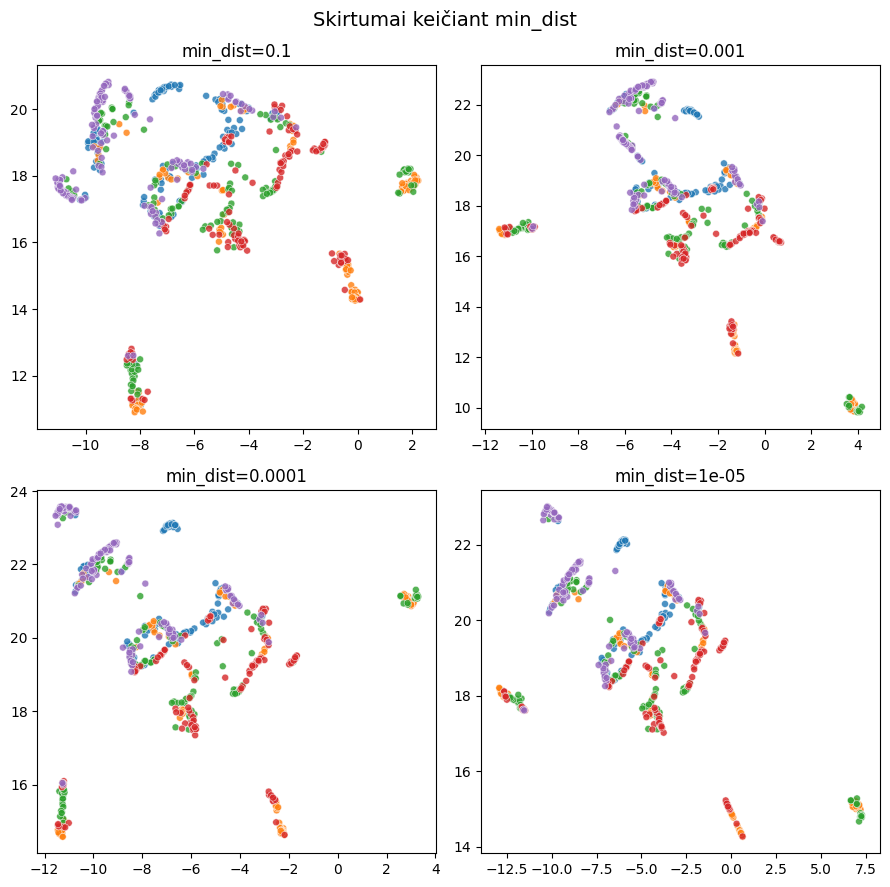

In [12]:

min_distances = [0.1, 0.001, 0.0001, 0.00001]
fig, axs = plt.subplots(2, 2, figsize=(9, 9))
axs = axs.flatten()
fig.suptitle('Skirtumai keičiant min_dist', fontsize=14)
for i, n in enumerate(min_distances):
    plot_umap(data=dist_mat, min_dist=n, ax=axs[i], var='min_dist')
plt.tight_layout()
plt.show()


n_neighbors=5 | CA Cont 0.0379 | CA Trust 0.0383 | KNN 0.642 | Geriausias k KNN 5 |
n_neighbors=10 | CA Cont 0.0393 | CA Trust 0.0395 | KNN 0.650 | Geriausias k KNN 5 |
n_neighbors=20 | CA Cont 0.0395 | CA Trust 0.0395 | KNN 0.609 | Geriausias k KNN 6 |
n_neighbors=50 | CA Cont 0.0394 | CA Trust 0.0391 | KNN 0.585 | Geriausias k KNN 5 |


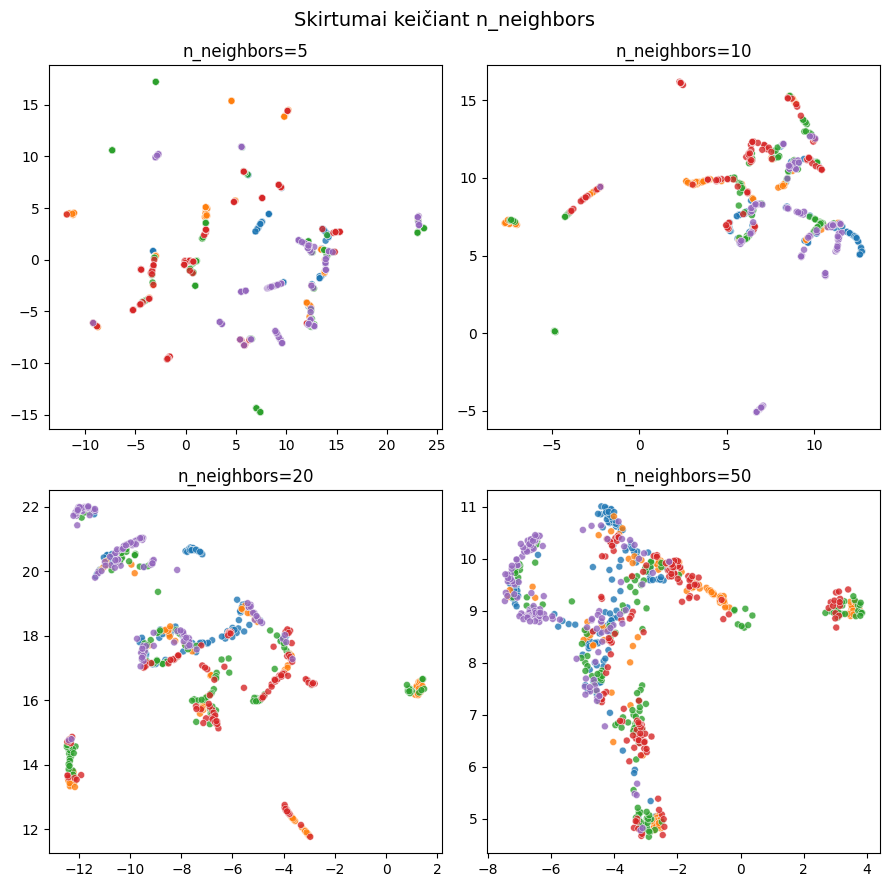

In [13]:

neighbors = [5, 10, 20, 50]
fig, axs = plt.subplots(2, 2, figsize=(9, 9))
axs = axs.flatten()
fig.suptitle('Skirtumai keičiant n_neighbors', fontsize=14)
for i, n in enumerate(neighbors):
    plot_umap(data=dist_mat, n_neighbors=n, ax=axs[i], var='n_neighbors')
plt.tight_layout()
plt.show()


n_epochs=25 | CA Cont 0.0395 | CA Trust 0.0393 | KNN 0.608 | Geriausias k KNN 5 |
n_epochs=50 | CA Cont 0.0396 | CA Trust 0.0394 | KNN 0.623 | Geriausias k KNN 6 |
n_epochs=100 | CA Cont 0.0396 | CA Trust 0.0394 | KNN 0.589 | Geriausias k KNN 6 |
n_epochs=300 | CA Cont 0.0395 | CA Trust 0.0395 | KNN 0.605 | Geriausias k KNN 8 |


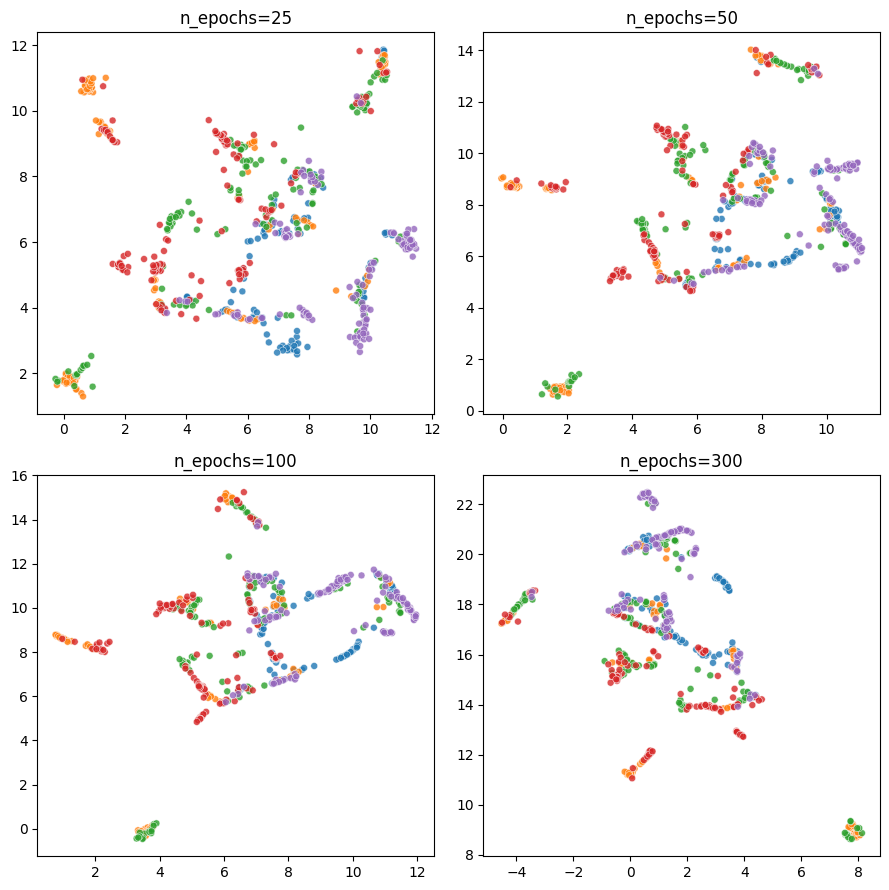

In [14]:

epochs = [25, 50, 100, 300]
fig, axs = plt.subplots(2, 2, figsize=(9, 9))
axs = axs.flatten()
for i, e in enumerate(epochs):
    plot_umap(data=dist_mat, n_epochs=e, ax=axs[i], var="n_epochs")
plt.tight_layout()
plt.show()


learning_rate=1.0 | CA Cont 0.0395 | CA Trust 0.0395 | KNN 0.609 | Geriausias k KNN 6 |
learning_rate=5.0 | CA Cont 0.0396 | CA Trust 0.0395 | KNN 0.613 | Geriausias k KNN 6 |
learning_rate=10 | CA Cont 0.0396 | CA Trust 0.0394 | KNN 0.599 | Geriausias k KNN 5 |
learning_rate=15 | CA Cont 0.0395 | CA Trust 0.0393 | KNN 0.594 | Geriausias k KNN 6 |


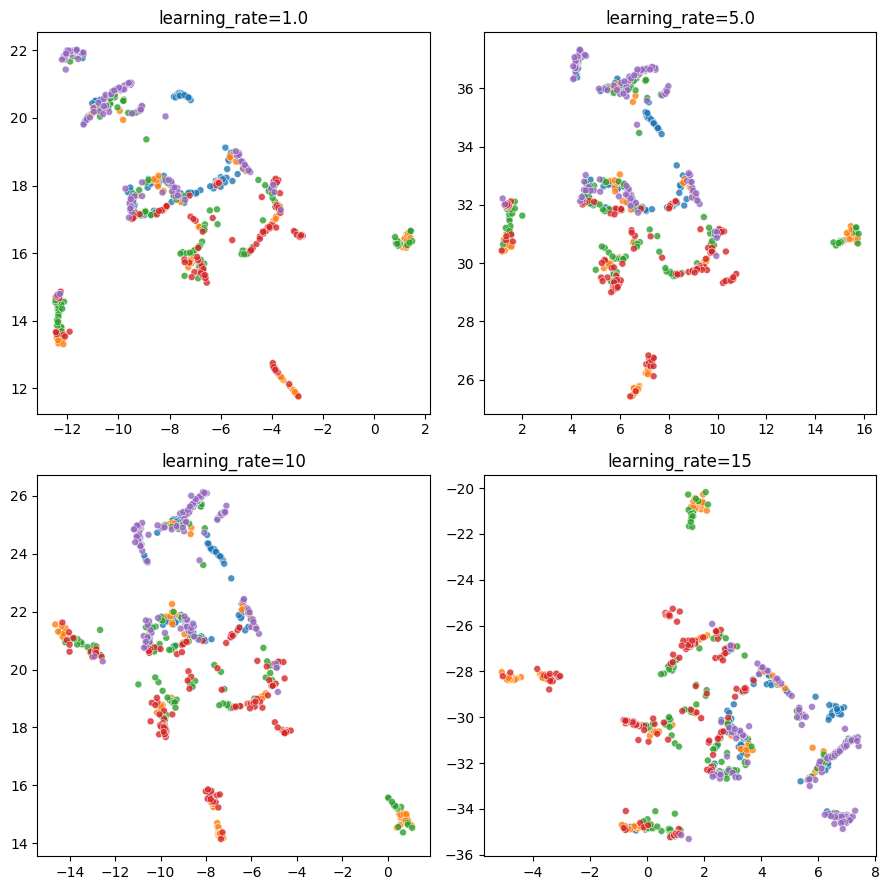

In [15]:

rates = [1.0, 5.0, 10, 15]
fig, axs = plt.subplots(2, 2, figsize=(9, 9))
axs = axs.flatten()
for i, r in enumerate(rates):
    plot_umap(data=dist_mat, learning_rate=r, ax=axs[i], var="learning_rate")
plt.tight_layout()
plt.show()



In [16]:

min_dists = [0.001, 0.01]
neighbors = [10, 20, 50]
epochs = [25, 50, 100]
rates = [1.0, 5.0, 10]

print("\nRunning UMAP grid search...")
results_df, best_params_umap = search_umap_params(
    dist_mat, labels, neighbors, min_dists, epochs, rates
)



Running UMAP grid search...
Testing: neighbors=10, min_dist=0.001, epochs=25, lr=1.0
Testing: neighbors=10, min_dist=0.001, epochs=25, lr=5.0
Testing: neighbors=10, min_dist=0.001, epochs=25, lr=10
Testing: neighbors=10, min_dist=0.001, epochs=50, lr=1.0
Testing: neighbors=10, min_dist=0.001, epochs=50, lr=5.0
Testing: neighbors=10, min_dist=0.001, epochs=50, lr=10
Testing: neighbors=10, min_dist=0.001, epochs=100, lr=1.0
Testing: neighbors=10, min_dist=0.001, epochs=100, lr=5.0
Testing: neighbors=10, min_dist=0.001, epochs=100, lr=10
Testing: neighbors=10, min_dist=0.01, epochs=25, lr=1.0
Testing: neighbors=10, min_dist=0.01, epochs=25, lr=5.0
Testing: neighbors=10, min_dist=0.01, epochs=25, lr=10
Testing: neighbors=10, min_dist=0.01, epochs=50, lr=1.0
Testing: neighbors=10, min_dist=0.01, epochs=50, lr=5.0
Testing: neighbors=10, min_dist=0.01, epochs=50, lr=10
Testing: neighbors=10, min_dist=0.01, epochs=100, lr=1.0
Testing: neighbors=10, min_dist=0.01, epochs=100, lr=5.0
Testing: n

# kiekvieno metodo geriausiu parametru radimas

In [17]:

def print_individual_bests(all_results_array):
    df = pd.DataFrame(all_results_array)
    # Calculate combined score using exactly your logic
    df["overall_score"] = df["knn_accuracy"] + df["ca_trustworthiness"] + df["ca_continuity"]
    
    methods = ["MDS", "t-SNE", "UMAP"]
    
    for method in methods:
        method_df = df[df["Method"] == method]
        if not method_df.empty:
            best = method_df.sort_values("overall_score", ascending=False).iloc[0]
            
            print(f"\n--- BEST {method.upper()} CONFIGURATION ---")
            print(f"Score:               {best['overall_score']:.4f}")
            print(f"KNN Accuracy:        {best['knn_accuracy']:.4f}")
            print(f"CA Trustworthiness:  {best['ca_trustworthiness']:.4f}")
            print(f"CA Continuity:       {best['ca_continuity']:.4f}")
            
            # Print only hyperparameters
            standard_cols = ['Method', 'overall_score', 'knn_accuracy', 'ca_trustworthiness', 'ca_continuity', 'best_k', 'embedding']
            hyperparams = {k: v for k, v in best.items() if k not in standard_cols and pd.notna(v)}
            print(f"Parameters:          {hyperparams}")

print_individual_bests(global_all_results)


--- BEST MDS CONFIGURATION ---
Score:               0.6760
KNN Accuracy:        0.5987
CA Trustworthiness:  0.0380
CA Continuity:       0.0393
Parameters:          {'n_init': np.float64(4.0)}

--- BEST T-SNE CONFIGURATION ---
Score:               0.7772
KNN Accuracy:        0.6998
CA Trustworthiness:  0.0386
CA Continuity:       0.0388
Parameters:          {'max_iter': np.float64(500.0), 'perplexity': np.float64(5.0), 'early_exaggeration': np.float64(12.0), 'learning_rate': np.float64(1000.0)}

--- BEST UMAP CONFIGURATION ---
Score:               2.6852
KNN Accuracy:        0.7227
CA Trustworthiness:  0.9810
CA Continuity:       0.9815
Parameters:          {'learning_rate': np.float64(1.0), 'n_neighbors': np.float64(10.0), 'min_dist': np.float64(0.01), 'n_epochs': np.float64(25.0)}


# geriausio metodo radimas

In [18]:

def find_best_overall_method(all_results_array):
    df = pd.DataFrame(all_results_array)
    df["overall_score"] = df["knn_accuracy"] + df["ca_trustworthiness"] + df["ca_continuity"]
    
    best = df.sort_values("overall_score", ascending=False).iloc[0]
    
    print("\n" + "="*60)
    print("="*60)
    print(f"Algorithm:           {best['Method']}")
    print(f"Overall Score:       {best['overall_score']:.4f}")
    print(f"KNN Accuracy:        {best['knn_accuracy']:.4f}")
    print(f"CA Trustworthiness:  {best['ca_trustworthiness']:.4f}")
    print(f"CA Continuity:       {best['ca_continuity']:.4f}")
    print("-" * 60)
    
    standard_cols = ['Method', 'overall_score', 'knn_accuracy', 'ca_trustworthiness', 'ca_continuity', 'best_k', 'embedding']
    hyperparams = {k: v for k, v in best.items() if k not in standard_cols and pd.notna(v)}
    
    print(f"Hyperparameters: \n{hyperparams}")
    print("="*60)
    
    return best

best_overall = find_best_overall_method(global_all_results)


Algorithm:           UMAP
Overall Score:       2.6852
KNN Accuracy:        0.7227
CA Trustworthiness:  0.9810
CA Continuity:       0.9815
------------------------------------------------------------
Hyperparameters: 
{'learning_rate': np.float64(1.0), 'n_neighbors': np.float64(10.0), 'min_dist': np.float64(0.01), 'n_epochs': np.float64(25.0)}
